# A/B TESTING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import zt_ind_solve_power


In [3]:
# Load dataset
ab_data = pd.read_csv('../data/cleaned/ab_test_cleaned.csv')
ab_data.head()

,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,864975,52:26.2,control,old_page,1,US
3,936923,20:49.1,control,old_page,0,US
4,719014,48:29.5,control,old_page,0,US


In [4]:
ab_data.tail()

,id,time,con_treat,page,converted,country
290579,677163,41:51.9,treatment,new_page,0,US
290580,925675,38:26.3,treatment,new_page,0,US
290581,643562,20:05.5,treatment,new_page,0,CA
290582,822004,36:46.1,treatment,new_page,0,CA
290583,715931,40:24.5,treatment,new_page,0,UK


## Exploratory Data Analysis

#### User Distribution by Country

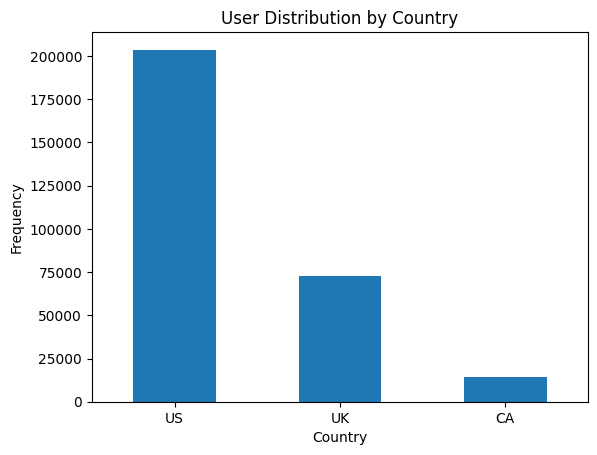

In [5]:
ab_data['country'].value_counts().plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.title('User Distribution by Country')
plt.show()

### User Distribution by group

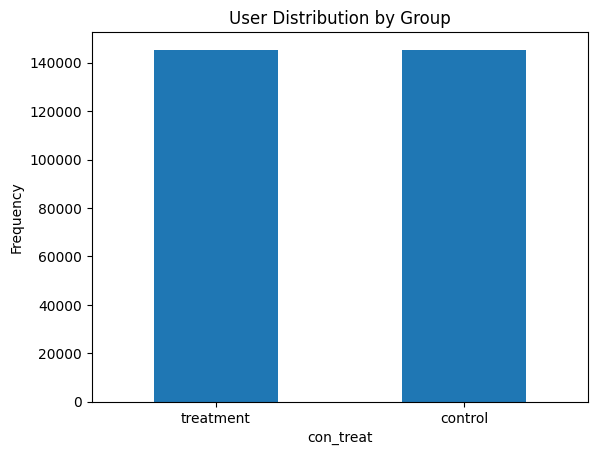

In [6]:
ab_data['con_treat'].value_counts().plot(kind='bar')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.title('User Distribution by Group')
plt.show()

### Conversi Rate

In [7]:
conversion_rate = ab_data.groupby('con_treat').agg({
    'converted' : 'mean'
})
conversion_rate

,converted
con_treat,
control,0.120297
treatment,0.118843


The conversion rate for the control group was 12.03%, slightly higher than the treatment group's 11.88%. This preliminary result indicates that users exposed to the old page converted marginally more often than those exposed to the new page. However, a statistical significance test is required to determine whether this difference is meaningful or simply due to random variation.

## perform z-test

In [8]:
# split dataset into control and treatment groups
control = ab_data[ab_data['con_treat'] == 'control']
treatment = ab_data[ab_data['con_treat'] == 'treatment']

# count the number of successful conversion in each group
success = [
    control['converted'].sum(),
    treatment['converted'].sum()
]

# count the total number of observations in each group
nobs = [
    len(control),
    len(treatment)
]

# Perform a two-proportion z-test to compare conversion rates
z_test, p_value = proportions_ztest(count=success, nobs=nobs)

# print test result
print("Z-statistic:", z_test)
print("P-value:", p_value)

Z-statistic: 1.2083846739740718
P-value: 0.22689933216132785


In [9]:
alpha = 0.05

if p_value < alpha:
    print('Reject H0')
else:
    print('Fail to reject H0')

Fail to reject H0


The A/B test results indicate that the difference in conversion rates between the control and treatment groups is not statistically significant (p-value = 0.2269). Therefore, there is insufficient evidence to conclude that the new page performs differently from the old page.

## confidance interval of the test

In [10]:
conversion_rate

,converted
con_treat,
control,0.120297
treatment,0.118843


In [11]:
# conversion rate
control_cr = conversion_rate.loc['control','converted']
treatment_cr = conversion_rate.loc['treatment', 'converted']

# sample size
n_control = len(control)
n_treatment = len(treatment)

# difference in conversion rate
diff = treatment_cr - control_cr

# standard error
se = np.sqrt(
    (control_cr * (1-control_cr) / n_control) + (treatment_cr * (1 - treatment_cr) / n_treatment)
)

# 95% confidence interval
lower = diff - 1.96 * se
upper = diff + 1.96 * se

print(f"Difference: {diff:.4f}")
print(f"95% CI: ({lower:.5f}, {upper:.5f})")

Difference: -0.0015
95% CI: (-0.00381, 0.00090)


A 95% confident that the true difference in conversion rates lies between -0.65% and 0.35%. The observed difference is not statistically significant at the 95% confidence level.

## power analysis

In [14]:
# calculate effect size
effect_size = proportion_effectsize(
    control_cr,
    treatment_cr
)

# estimate the required sample size per group
# to achive 80% statistical power
sample_size = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print(f'effect size: {effect_size}')
print(f'required sample size: {round(sample_size)}')

effect size: 0.004483330805719499
required sample size: 780971


In [15]:
# calculate the statistical power of the experiment
# using the observed effect size and actual sample size
power = zt_ind_solve_power(
    effect_size=effect_size,
    nobs1=n_control,
    alpha=0.05,
    alternative='two-sided'
)

print(f'power: {power}')

power: 0.226845378038678


Power analysis showed that the experiment achieved only 22.7% statistical power, which is substantially below the commonly recommended threshold of 80%. Based on the observed effect size, approximately 780,971 users per group would be required to reliably detect such a small difference. Therefore, the experiment was underpowered, and the non-significant result should be interpreted with caution.